<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week14/Day1%262/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge: Data Cleaning and Transformation with the Global Terrorism Database

## Google Colab Version

This notebook performs:

1. Initial dataset assessment
2. Data cleaning
3. Missing-value treatment
4. Data-type correction
5. Categorical transformation
6. Numerical normalization
7. Exploratory data analysis
8. Visualizations
9. Export of the cleaned dataset
10. Creation of a `.gitignore` file

Before running the notebook, upload the Global Terrorism Database file to the Colab session.

Supported formats:

- `.csv`
- `.xlsx`
- `.xls`
- `.zip` containing a CSV or Excel file


## 1. Install and import the required libraries

In [1]:
%pip install -q openpyxl xlrd

import os
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from google.colab import files

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Upload the dataset

Run this cell and select the Global Terrorism Database file from your computer.

If you already uploaded the file using the Colab file panel, the notebook will also detect it automatically.


In [2]:
uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving Global Terrorism Database (1).zip to Global Terrorism Database (1).zip

Uploaded files:
- Global Terrorism Database (1).zip


## 3. Detect and load the dataset automatically

The following function:

- Searches for CSV, Excel, or ZIP files.
- Extracts ZIP files when necessary.
- Tries different CSV encodings.
- Loads the largest compatible file, which is normally the GTD dataset.


In [3]:
DATA_FOLDER = Path("/content")
SUPPORTED_EXTENSIONS = {".csv", ".xlsx", ".xls", ".zip"}


def extract_zip_files(folder):
    zip_files = list(folder.glob("*.zip"))

    for zip_path in zip_files:
        extract_folder = folder / zip_path.stem
        extract_folder.mkdir(exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_folder)

        print(f"✅ Extracted: {zip_path.name}")


def find_dataset_files(folder):
    candidates = []

    for path in folder.rglob("*"):
        if (
            path.is_file()
            and path.suffix.lower() in {".csv", ".xlsx", ".xls"}
        ):
            candidates.append(path)

    return sorted(
        candidates,
        key=lambda path: path.stat().st_size,
        reverse=True
    )


def load_csv_with_fallbacks(path):
    encodings = ["utf-8", "latin-1", "ISO-8859-1", "cp1252"]

    for encoding in encodings:
        try:
            return pd.read_csv(
                path,
                encoding=encoding,
                low_memory=False
            )
        except UnicodeDecodeError:
            continue

    raise ValueError(
        f"Could not decode CSV file: {path.name}"
    )


def load_dataset(path):
    extension = path.suffix.lower()

    if extension == ".csv":
        return load_csv_with_fallbacks(path)

    if extension in {".xlsx", ".xls"}:
        return pd.read_excel(path)

    raise ValueError(
        f"Unsupported file type: {extension}"
    )


extract_zip_files(DATA_FOLDER)

dataset_files = find_dataset_files(DATA_FOLDER)

if not dataset_files:
    raise FileNotFoundError(
        "No CSV or Excel dataset was found. "
        "Upload the GTD file and run the cell again."
    )

dataset_path = dataset_files[0]

print("Selected dataset:", dataset_path)
print(
    "File size:",
    round(dataset_path.stat().st_size / (1024 ** 2), 2),
    "MB"
)

df_raw = load_dataset(dataset_path)

print("\n✅ Dataset loaded successfully")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

✅ Extracted: Global Terrorism Database (1).zip
Selected dataset: /content/Global Terrorism Database (1)/Global Terrorism Database/Global Terrorism Database/globalterrorismdb_0718dist.csv
File size: 155.27 MB

✅ Dataset loaded successfully
Rows: 181691
Columns: 135


## 4. Initial assessment

We inspect:

- Shape
- Column names
- Sample rows
- Data types
- Missing values
- Duplicated rows


In [4]:
print("Dataset shape:", df_raw.shape)

print("\nFirst five rows:")
display(df_raw.head())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(
    df_raw.dtypes
          .astype(str)
          .rename("data_type")
          .to_frame()
          .head(50)
)

print("\nDuplicated rows:", df_raw.duplicated().sum())

Dataset shape: (181691, 135)

First five rows:


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,region_txt,provstate,city,latitude,longitude,specificity,vicinity,location,summary,crit1,crit2,crit3,doubtterr,alternative,alternative_txt,multiple,success,suicide,attacktype1,attacktype1_txt,attacktype2,attacktype2_txt,attacktype3,attacktype3_txt,targtype1,targtype1_txt,targsubtype1,targsubtype1_txt,corp1,target1,natlty1,natlty1_txt,targtype2,targtype2_txt,targsubtype2,targsubtype2_txt,corp2,target2,natlty2,natlty2_txt,...,weaptype2,weaptype2_txt,weapsubtype2,weapsubtype2_txt,weaptype3,weaptype3_txt,weapsubtype3,weapsubtype3_txt,weaptype4,weaptype4_txt,weapsubtype4,weapsubtype4_txt,weapdetail,nkill,nkillus,nkillter,nwound,nwoundus,nwoundte,property,propextent,propextent_txt,propvalue,propcomment,ishostkid,nhostkid,nhostkidus,nhours,ndays,divert,kidhijcountry,ransom,ransomamt,ransomamtus,ransompaid,ransompaidus,ransomnote,hostkidoutcome,hostkidoutcome_txt,nreleased,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,Central America & Caribbean,NaN,Santo Domingo,18.456792,-69.951164,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,14,Private Citizens & Property,68.0,Named Civilian,NaN,Julio Guzman,58.0,Dominican Republic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,North America,Federal,Mexico city,19.371887,-99.086624,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,6,Hostage Taking (Kidnapping),NaN,NaN,NaN,NaN,7,Government (Diplomatic),45.0,"Diplomatic Personnel (outside of embassy, consulate)",Belgian Ambassador Daughter,"Nadine Chaval, daughter",21.0,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,NaN,Mexico,1.0,800000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,4.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,10,Journalists & Media,54.0,Radio Journalist/Staff/Facility,Voice of America,Employee,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,Western Europe,Attica,Athens,37.997490,23.762728,1.0,0,NaN,NaN,1,1,1,0.0,NaN,NaN,0.0,1,0,3,Bombing/Explosion,NaN,NaN,NaN,NaN,7,Government (Diplomatic),46.0,Embassy/Consulate,NaN,U.S. Embassy,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Explosive,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,East Asia,Fukouka,Fukouka,33.580412,130.396361,1.0,0,NaN,NaN,1,1,1,-9.0,NaN,NaN,0.0,1,0,7,Facility/Infrastructure Attack,NaN,NaN,NaN,NaN,7,Government (Diplomatic),46.0,Embassy/Consulate,NaN,U.S. Consulate,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Incendiary,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN



Column names:
['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'claim2', 'clai

,data_type
eventid,int64
iyear,int64
imonth,int64
iday,int64
approxdate,object
extended,int64
resolution,object
country,int64
country_txt,object
region,int64



Duplicated rows: 0


In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percentage": (
        df_raw.isna().mean() * 100
    ).round(2)
}).sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary.head(30))

,missing_count,missing_percentage
gsubname3,181671,99.99
weaptype4_txt,181618,99.96
weapsubtype4_txt,181621,99.96
weapsubtype4,181621,99.96
weaptype4,181618,99.96
claimmode3,181558,99.93
claimmode3_txt,181558,99.93
gsubname2,181531,99.91
divert,181367,99.82
guncertain3,181371,99.82


## 5. Select the most relevant GTD columns

The complete GTD dataset contains many columns. For this challenge, we keep a focused set related to:

- Date
- Location
- Attack characteristics
- Weapons
- Victims
- Terrorist groups
- Targets
- Event success

The code only selects columns that are actually present, making it compatible with different GTD versions.


In [6]:
RELEVANT_COLUMNS = [
    "eventid",
    "iyear",
    "imonth",
    "iday",
    "country",
    "country_txt",
    "region",
    "region_txt",
    "provstate",
    "city",
    "latitude",
    "longitude",
    "success",
    "suicide",
    "attacktype1",
    "attacktype1_txt",
    "targtype1",
    "targtype1_txt",
    "target1",
    "natlty1",
    "natlty1_txt",
    "gname",
    "motive",
    "weaptype1",
    "weaptype1_txt",
    "nkill",
    "nkillus",
    "nkillter",
    "nwound",
    "nwoundus",
    "nwoundte",
    "property",
    "propextent",
    "propextent_txt",
    "ransom"
]

available_columns = [
    column
    for column in RELEVANT_COLUMNS
    if column in df_raw.columns
]

missing_expected_columns = [
    column
    for column in RELEVANT_COLUMNS
    if column not in df_raw.columns
]

df = df_raw[available_columns].copy()

print("Selected columns:", len(available_columns))
print("Dataset shape after selection:", df.shape)

if missing_expected_columns:
    print(
        "\nColumns not found in this GTD version:",
        missing_expected_columns
    )

Selected columns: 35
Dataset shape after selection: (181691, 35)


## 6. Clean column names and duplicate rows

In [7]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9_]+", "_", regex=True)
)

rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)

print("Rows removed as duplicates:", rows_before - rows_after)
print("Remaining rows:", rows_after)

Rows removed as duplicates: 0
Remaining rows: 181691


## 7. Handle invalid date values

In the GTD:

- Month `0` means unknown month.
- Day `0` means unknown day.

We replace these values with missing values and create a valid date column. Unknown month or day values are temporarily replaced with `1` only for date construction, while the original cleaned month/day columns preserve missing values.


In [8]:
for column in ["iyear", "imonth", "iday"]:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

if "imonth" in df.columns:
    df.loc[
        ~df["imonth"].between(1, 12),
        "imonth"
    ] = np.nan

if "iday" in df.columns:
    df.loc[
        ~df["iday"].between(1, 31),
        "iday"
    ] = np.nan

if "iyear" in df.columns:
    date_frame = pd.DataFrame({
        "year": df["iyear"],
        "month": df.get(
            "imonth",
            pd.Series(1, index=df.index)
        ).fillna(1),
        "day": df.get(
            "iday",
            pd.Series(1, index=df.index)
        ).fillna(1)
    })

    df["event_date"] = pd.to_datetime(
        date_frame,
        errors="coerce"
    )

print("Invalid event dates:", df["event_date"].isna().sum())
display(
    df[
        [
            column
            for column in [
                "iyear",
                "imonth",
                "iday",
                "event_date"
            ]
            if column in df.columns
        ]
    ].head()
)

Invalid event dates: 0


,iyear,imonth,iday,event_date
0,1970,7.0,2.0,1970-07-02
1,1970,NaN,NaN,1970-01-01
2,1970,1.0,NaN,1970-01-01
3,1970,1.0,NaN,1970-01-01
4,1970,1.0,NaN,1970-01-01


## 8. Correct data types

Binary variables are converted to nullable integer values.

Victim counts, coordinates, and codes are converted to numeric values.


In [9]:
BINARY_COLUMNS = [
    "success",
    "suicide",
    "property",
    "ransom"
]

NUMERIC_COLUMNS = [
    "latitude",
    "longitude",
    "nkill",
    "nkillus",
    "nkillter",
    "nwound",
    "nwoundus",
    "nwoundte",
    "country",
    "region",
    "attacktype1",
    "targtype1",
    "natlty1",
    "weaptype1",
    "propextent"
]

for column in BINARY_COLUMNS:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

        df.loc[
            ~df[column].isin([0, 1]),
            column
        ] = np.nan

        df[column] = df[column].astype("Int64")

for column in NUMERIC_COLUMNS:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("✅ Data types corrected")

display(
    df.dtypes
      .astype(str)
      .rename("data_type")
      .to_frame()
)

✅ Data types corrected


,data_type
eventid,int64
iyear,int64
imonth,float64
iday,float64
country,int64
country_txt,object
region,int64
region_txt,object
provstate,object
city,object


## 9. Clean text and categorical columns

Missing category labels are replaced with `"Unknown"`.

Text columns are stripped of extra spaces.


In [10]:
TEXT_COLUMNS = [
    "country_txt",
    "region_txt",
    "provstate",
    "city",
    "attacktype1_txt",
    "targtype1_txt",
    "target1",
    "natlty1_txt",
    "gname",
    "motive",
    "weaptype1_txt",
    "propextent_txt"
]

for column in TEXT_COLUMNS:
    if column in df.columns:
        df[column] = (
            df[column]
              .astype("string")
              .str.strip()
              .replace({
                  "": pd.NA,
                  "nan": pd.NA,
                  "Unknown": pd.NA,
                  "-9": pd.NA
              })
        )

CATEGORICAL_COLUMNS = [
    "country_txt",
    "region_txt",
    "provstate",
    "city",
    "attacktype1_txt",
    "targtype1_txt",
    "natlty1_txt",
    "gname",
    "weaptype1_txt",
    "propextent_txt"
]

for column in CATEGORICAL_COLUMNS:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")

print("✅ Text and categorical columns cleaned")

✅ Text and categorical columns cleaned


## 10. Handle missing numerical values

For victim-count columns:

- Missing values are filled with `0` for analytical convenience.
- A separate indicator column records whether the original value was missing.

This avoids losing information about data quality.


In [11]:
CASUALTY_COLUMNS = [
    "nkill",
    "nkillus",
    "nkillter",
    "nwound",
    "nwoundus",
    "nwoundte"
]

for column in CASUALTY_COLUMNS:
    if column in df.columns:
        df[f"{column}_was_missing"] = (
            df[column].isna().astype(int)
        )

        df[column] = (
            df[column]
              .fillna(0)
              .clip(lower=0)
        )

if "nkill" in df.columns and "nwound" in df.columns:
    df["total_casualties"] = (
        df["nkill"] + df["nwound"]
    )

print("✅ Missing casualty values handled")

✅ Missing casualty values handled


## 11. Detect extreme values

Terrorism data may naturally contain extreme casualty values. These observations should not automatically be removed because they may represent real major attacks.

We inspect them instead of deleting them.


In [12]:
outlier_summary = {}

for column in ["nkill", "nwound", "total_casualties"]:
    if column in df.columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        upper_limit = q3 + 1.5 * iqr

        outlier_summary[column] = {
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "upper_limit": upper_limit,
            "outlier_count": int(
                (df[column] > upper_limit).sum()
            )
        }

outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

print(
    "Extreme casualty values were retained because "
    "they may represent real historical events."
)

,q1,q3,iqr,upper_limit,outlier_count
nkill,0.0,2.0,2.0,5.0,16242.0
nwound,0.0,2.0,2.0,5.0,19850.0
total_casualties,0.0,4.0,4.0,10.0,18856.0


Extreme casualty values were retained because they may represent real historical events.


## 12. Create transformed features

We create:

- Decade
- Year-month
- Casualty severity category
- Indicator showing whether the terrorist group is known


In [13]:
if "iyear" in df.columns:
    df["decade"] = (
        (df["iyear"] // 10) * 10
    ).astype("Int64")

if "event_date" in df.columns:
    df["year_month"] = (
        df["event_date"]
          .dt.to_period("M")
          .astype(str)
    )

if "total_casualties" in df.columns:
    df["severity_level"] = pd.cut(
        df["total_casualties"],
        bins=[-1, 0, 5, 20, np.inf],
        labels=[
            "No casualties",
            "Low",
            "Medium",
            "High"
        ]
    )

if "gname" in df.columns:
    df["known_group"] = (
        df["gname"]
          .ne("Unknown")
          .astype(int)
    )

print("✅ New analytical features created")

✅ New analytical features created


## 13. One-hot encode categorical variables

To avoid creating thousands of columns, we encode selected low-cardinality variables:

- Region
- Attack type
- Weapon type
- Severity level

High-cardinality columns such as city, country, group name, and target name are not one-hot encoded.


In [14]:
ENCODING_COLUMNS = [
    column
    for column in [
        "region_txt",
        "attacktype1_txt",
        "weaptype1_txt",
        "severity_level"
    ]
    if column in df.columns
]

encoded_features = pd.get_dummies(
    df[ENCODING_COLUMNS],
    prefix=ENCODING_COLUMNS,
    dtype=int
)

print("Encoded variables:", ENCODING_COLUMNS)
print("Number of encoded columns:", encoded_features.shape[1])

display(encoded_features.head())

Encoded variables: ['region_txt', 'attacktype1_txt', 'weaptype1_txt', 'severity_level']
Number of encoded columns: 37


,region_txt_Australasia & Oceania,region_txt_Central America & Caribbean,region_txt_Central Asia,region_txt_East Asia,region_txt_Eastern Europe,region_txt_Middle East & North Africa,region_txt_North America,region_txt_South America,region_txt_South Asia,region_txt_Southeast Asia,region_txt_Sub-Saharan Africa,region_txt_Western Europe,attacktype1_txt_Armed Assault,attacktype1_txt_Assassination,attacktype1_txt_Bombing/Explosion,attacktype1_txt_Facility/Infrastructure Attack,attacktype1_txt_Hijacking,attacktype1_txt_Hostage Taking (Barricade Incident),attacktype1_txt_Hostage Taking (Kidnapping),attacktype1_txt_Unarmed Assault,attacktype1_txt_Unknown,weaptype1_txt_Biological,weaptype1_txt_Chemical,weaptype1_txt_Explosives,weaptype1_txt_Fake Weapons,weaptype1_txt_Firearms,weaptype1_txt_Incendiary,weaptype1_txt_Melee,weaptype1_txt_Other,weaptype1_txt_Radiological,weaptype1_txt_Sabotage Equipment,weaptype1_txt_Unknown,"weaptype1_txt_Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",severity_level_No casualties,severity_level_Low,severity_level_Medium,severity_level_High
0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


## 14. Normalize numerical variables

We create two normalized versions:

- **StandardScaler**: mean `0`, standard deviation `1`
- **MinMaxScaler**: values between `0` and `1`

The original numerical columns remain unchanged.


In [15]:
NORMALIZATION_COLUMNS = [
    column
    for column in [
        "nkill",
        "nwound",
        "total_casualties"
    ]
    if column in df.columns
]

standardized_features = pd.DataFrame(
    index=df.index
)

minmax_features = pd.DataFrame(
    index=df.index
)

if NORMALIZATION_COLUMNS:
    standard_scaler = StandardScaler()
    minmax_scaler = MinMaxScaler()

    standardized_values = standard_scaler.fit_transform(
        df[NORMALIZATION_COLUMNS]
    )

    minmax_values = minmax_scaler.fit_transform(
        df[NORMALIZATION_COLUMNS]
    )

    standardized_features = pd.DataFrame(
        standardized_values,
        columns=[
            f"{column}_standardized"
            for column in NORMALIZATION_COLUMNS
        ],
        index=df.index
    )

    minmax_features = pd.DataFrame(
        minmax_values,
        columns=[
            f"{column}_minmax"
            for column in NORMALIZATION_COLUMNS
        ],
        index=df.index
    )

print("Normalized columns:", NORMALIZATION_COLUMNS)
display(standardized_features.head())

Normalized columns: ['nkill', 'nwound', 'total_casualties']


,nkill_standardized,nwound_standardized,total_casualties_standardized
0,-0.112840,-0.084037,-0.102333
1,-0.201911,-0.084037,-0.126991
2,-0.112840,-0.084037,-0.102333
3,-0.201911,-0.084037,-0.126991
4,-0.201911,-0.084037,-0.126991


## 15. Build the final transformed dataset

The final dataset combines:

- Cleaned original variables
- Engineered features
- One-hot encoded variables
- Standardized variables
- Min-max normalized variables


In [16]:
df_transformed = pd.concat(
    [
        df.reset_index(drop=True),
        encoded_features.reset_index(drop=True),
        standardized_features.reset_index(drop=True),
        minmax_features.reset_index(drop=True)
    ],
    axis=1
)

print("Cleaned dataset shape:", df.shape)
print("Transformed dataset shape:", df_transformed.shape)

display(df_transformed.head())

Cleaned dataset shape: (181691, 47)
Transformed dataset shape: (181691, 90)


,eventid,iyear,imonth,iday,country,country_txt,region,region_txt,provstate,city,latitude,longitude,success,suicide,attacktype1,attacktype1_txt,targtype1,targtype1_txt,target1,natlty1,natlty1_txt,gname,motive,weaptype1,weaptype1_txt,nkill,nkillus,nkillter,nwound,nwoundus,nwoundte,property,propextent,propextent_txt,ransom,event_date,nkill_was_missing,nkillus_was_missing,nkillter_was_missing,nwound_was_missing,nwoundus_was_missing,nwoundte_was_missing,total_casualties,decade,year_month,severity_level,known_group,region_txt_Australasia & Oceania,region_txt_Central America & Caribbean,region_txt_Central Asia,region_txt_East Asia,region_txt_Eastern Europe,region_txt_Middle East & North Africa,region_txt_North America,region_txt_South America,region_txt_South Asia,region_txt_Southeast Asia,region_txt_Sub-Saharan Africa,region_txt_Western Europe,attacktype1_txt_Armed Assault,attacktype1_txt_Assassination,attacktype1_txt_Bombing/Explosion,attacktype1_txt_Facility/Infrastructure Attack,attacktype1_txt_Hijacking,attacktype1_txt_Hostage Taking (Barricade Incident),attacktype1_txt_Hostage Taking (Kidnapping),attacktype1_txt_Unarmed Assault,attacktype1_txt_Unknown,weaptype1_txt_Biological,weaptype1_txt_Chemical,weaptype1_txt_Explosives,weaptype1_txt_Fake Weapons,weaptype1_txt_Firearms,weaptype1_txt_Incendiary,weaptype1_txt_Melee,weaptype1_txt_Other,weaptype1_txt_Radiological,weaptype1_txt_Sabotage Equipment,weaptype1_txt_Unknown,"weaptype1_txt_Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",severity_level_No casualties,severity_level_Low,severity_level_Medium,severity_level_High,nkill_standardized,nwound_standardized,total_casualties_standardized,nkill_minmax,nwound_minmax,total_casualties_minmax
0,197000000001,1970,7.0,2.0,58,Dominican Republic,2,Central America & Caribbean,Unknown,Santo Domingo,18.456792,-69.951164,1,0,1,Assassination,14,Private Citizens & Property,Julio Guzman,58.0,Dominican Republic,MANO-D,<NA>,13,Unknown,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,Unknown,0,1970-07-02,0,1,1,0,1,1,1.0,1970,1970-07,Low,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,-0.112840,-0.084037,-0.102333,0.000637,0.0,0.000104
1,197000000002,1970,NaN,NaN,130,Mexico,1,North America,Federal,Mexico city,19.371887,-99.086624,1,0,6,Hostage Taking (Kidnapping),7,Government (Diplomatic),"Nadine Chaval, daughter",21.0,Belgium,23rd of September Communist League,<NA>,13,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,Unknown,1,1970-01-01,0,1,1,0,1,1,0.0,1970,1970-01,No casualties,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,-0.201911,-0.084037,-0.126991,0.000000,0.0,0.000000
2,197001000001,1970,1.0,NaN,160,Philippines,5,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,1,0,1,Assassination,10,Journalists & Media,Employee,217.0,United States,Unknown,<NA>,13,Unknown,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,Unknown,0,1970-01-01,0,1,1,0,1,1,1.0,1970,1970-01,Low,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,-0.112840,-0.084037,-0.102333,0.000637,0.0,0.000104
3,197001000002,1970,1.0,NaN,78,Greece,8,Western Europe,Attica,Athens,37.997490,23.762728,1,0,3,Bombing/Explosion,7,Government (Diplomatic),U.S. Embassy,217.0,United States,Unknown,<NA>,6,Explosives,0.0,0.0,0.0,0.0,0.0,0.0,1,NaN,Unknown,0,1970-01-01,1,1,1,1,1,1,0.0,1970,1970-01,No casualties,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,-0.201911,-0.084037,-0.126991,0.000000,0.0,0.000000
4,197001000003,1970,1.0,NaN,101,Japan,4,East Asia,Fukouka,Fukouka,33.580412,130.396361,1,0,7,Facility/Infrastructure Attack,7,Government (Diplomatic),U.S. Consulate,217.0,United States,Unknown,<NA>,8,Incendiary,0.0,0.0,0.0,0.0,0.0,0.0,1,NaN,Unknown,0,1970-01-01,1,1,1,1,1,1,0.0,1970,1970-01,No casualties,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,-0.201911,-0.084037,-0.126991,0.000000,0.0,0.000000


# Exploratory Data Analysis

## 16. Summary statistics

In [17]:
summary_columns = [
    column
    for column in [
        "iyear",
        "nkill",
        "nwound",
        "total_casualties"
    ]
    if column in df.columns
]

display(
    df[summary_columns]
      .describe()
      .T
)

,count,mean,std,min,25%,50%,75%,max
iyear,181691.0,2002.638997,13.259430,1970.0,1991.0,2009.0,2014.0,2017.0
nkill,181691.0,2.266860,11.227057,0.0,0.0,0.0,2.0,1570.0
nwound,181691.0,2.883296,34.309747,0.0,0.0,0.0,2.0,8191.0
total_casualties,181691.0,5.150156,40.555416,0.0,0.0,1.0,4.0,9574.0


## 17. Number of terrorist events by year

,iyear,event_count
32,2003,1278
33,2004,1166
34,2005,2017
35,2006,2758
36,2007,3242
37,2008,4805
38,2009,4721
39,2010,4826
40,2011,5076
41,2012,8522


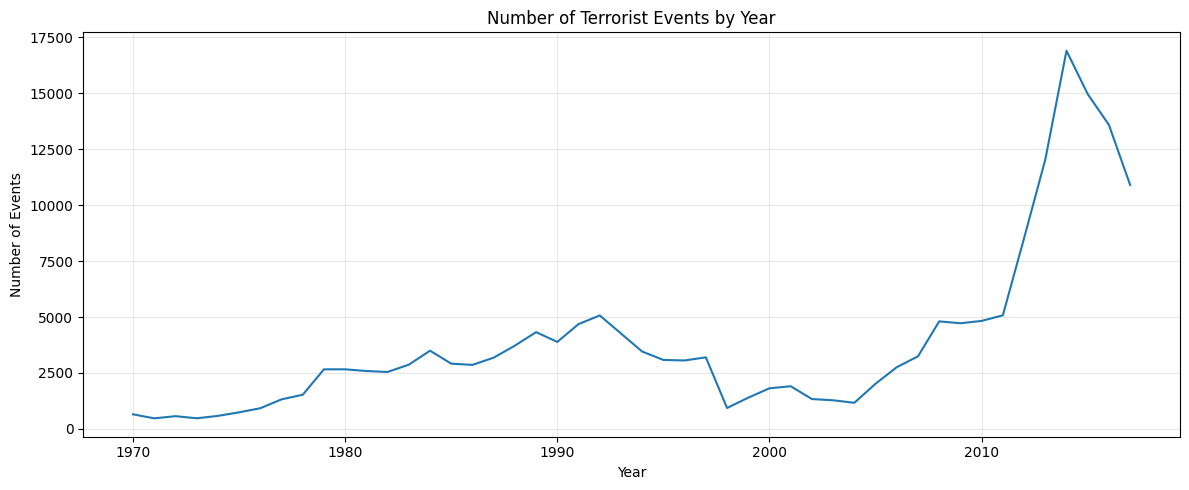

In [18]:
if "iyear" in df.columns:
    events_by_year = (
        df.groupby("iyear")
          .size()
          .rename("event_count")
          .reset_index()
    )

    display(events_by_year.tail(15))

    plt.figure(figsize=(12, 5))
    plt.plot(
        events_by_year["iyear"],
        events_by_year["event_count"]
    )
    plt.title("Number of Terrorist Events by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Events")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 18. Regions with the highest number of events

,event_count
region_txt,
Middle East & North Africa,50474
South Asia,44974
South America,18978
Sub-Saharan Africa,17550
Western Europe,16639
Southeast Asia,12485
Central America & Caribbean,10344
Eastern Europe,5144
North America,3456


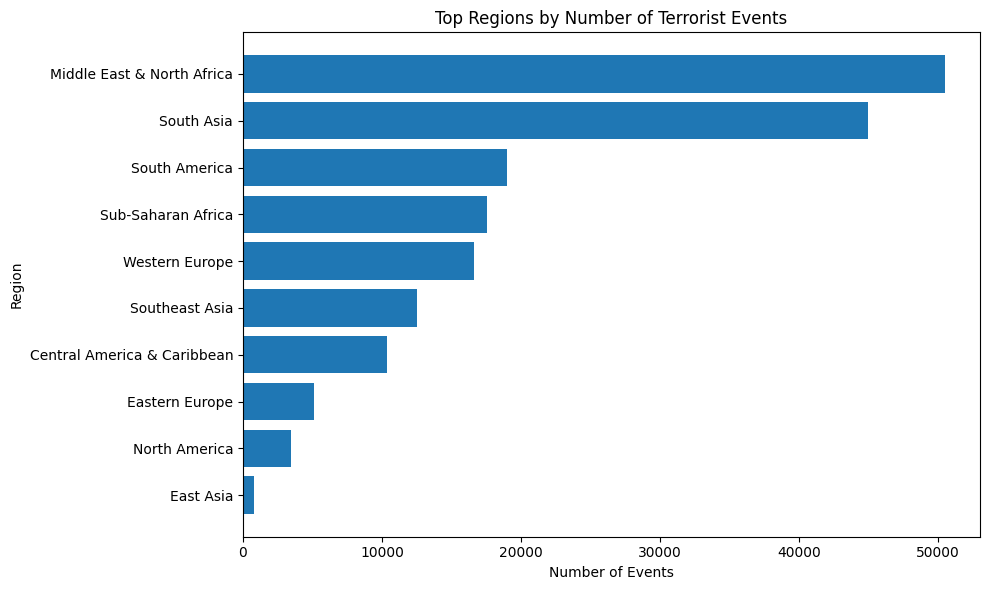

In [19]:
if "region_txt" in df.columns:
    top_regions = (
        df["region_txt"]
          .value_counts()
          .head(10)
          .sort_values()
    )

    display(
        top_regions
          .sort_values(ascending=False)
          .rename("event_count")
          .to_frame()
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_regions.index,
        top_regions.values
    )
    plt.title("Top Regions by Number of Terrorist Events")
    plt.xlabel("Number of Events")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()

## 19. Countries with the highest number of events

,event_count
country_txt,
Iraq,24636
Pakistan,14368
Afghanistan,12731
India,11960
Colombia,8306
Philippines,6908
Peru,6096
El Salvador,5320
United Kingdom,5235


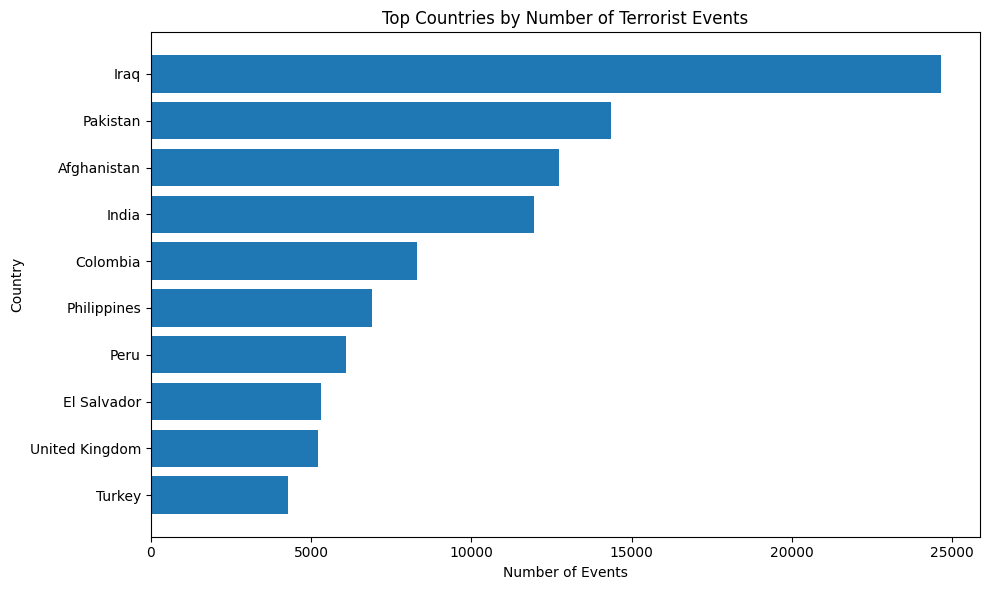

In [20]:
if "country_txt" in df.columns:
    top_countries = (
        df["country_txt"]
          .value_counts()
          .head(10)
          .sort_values()
    )

    display(
        top_countries
          .sort_values(ascending=False)
          .rename("event_count")
          .to_frame()
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_countries.index,
        top_countries.values
    )
    plt.title("Top Countries by Number of Terrorist Events")
    plt.xlabel("Number of Events")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

## 20. Most common attack types

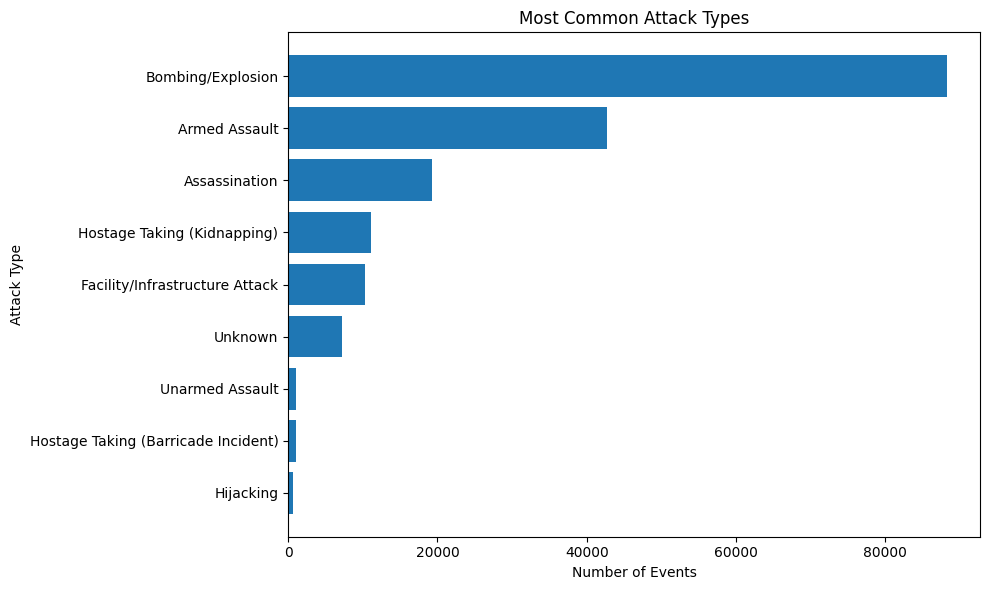

In [21]:
if "attacktype1_txt" in df.columns:
    attack_types = (
        df["attacktype1_txt"]
          .value_counts()
          .head(10)
          .sort_values()
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        attack_types.index,
        attack_types.values
    )
    plt.title("Most Common Attack Types")
    plt.xlabel("Number of Events")
    plt.ylabel("Attack Type")
    plt.tight_layout()
    plt.show()

## 21. Most common weapon types

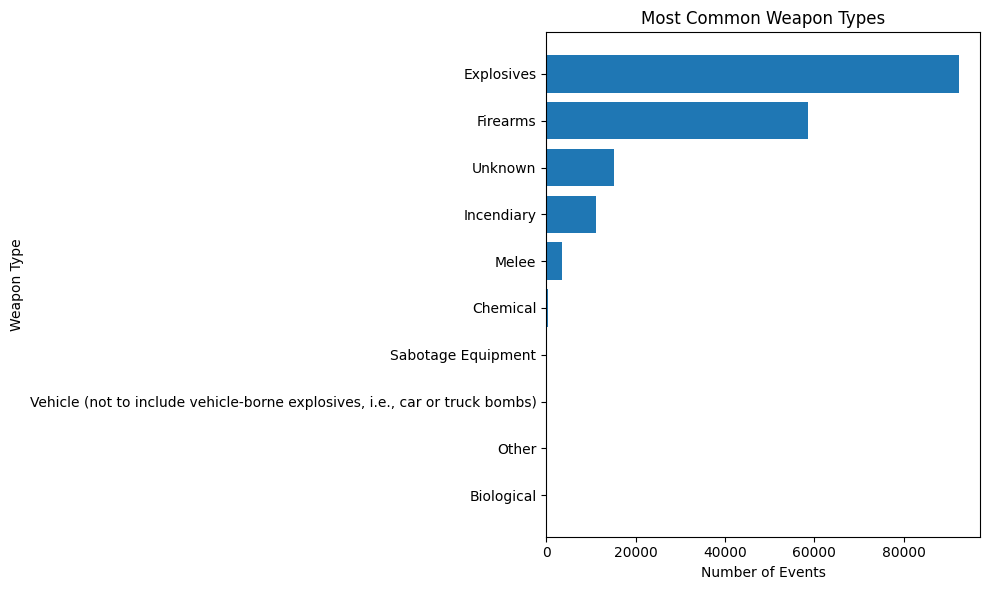

In [22]:
if "weaptype1_txt" in df.columns:
    weapon_types = (
        df["weaptype1_txt"]
          .value_counts()
          .head(10)
          .sort_values()
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        weapon_types.index,
        weapon_types.values
    )
    plt.title("Most Common Weapon Types")
    plt.xlabel("Number of Events")
    plt.ylabel("Weapon Type")
    plt.tight_layout()
    plt.show()

## 22. Casualties over time

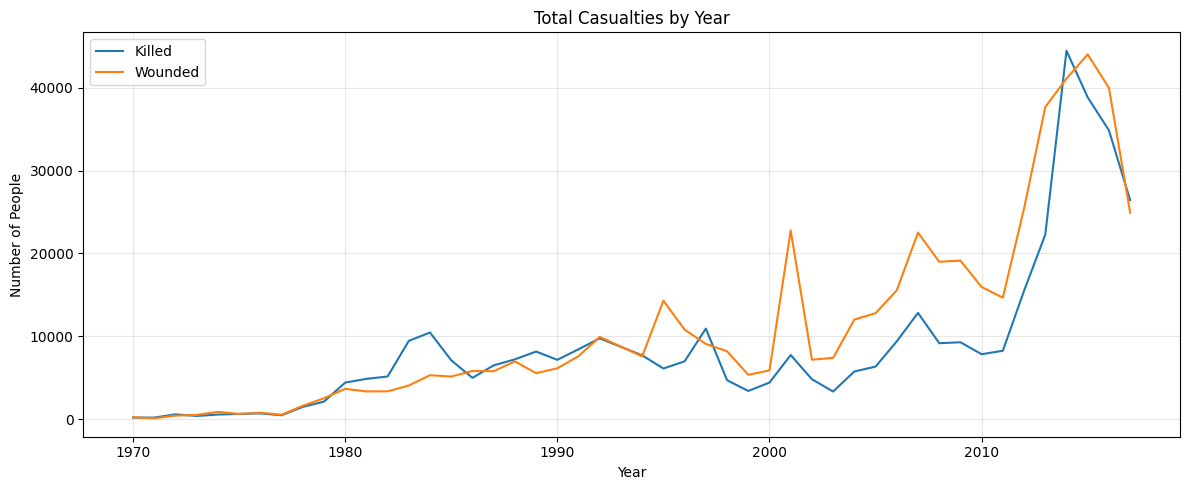

In [23]:
if {
    "iyear",
    "nkill",
    "nwound"
}.issubset(df.columns):

    casualties_by_year = (
        df.groupby("iyear")[["nkill", "nwound"]]
          .sum()
          .reset_index()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        casualties_by_year["iyear"],
        casualties_by_year["nkill"],
        label="Killed"
    )
    plt.plot(
        casualties_by_year["iyear"],
        casualties_by_year["nwound"],
        label="Wounded"
    )

    plt.title("Total Casualties by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of People")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 23. Event success rate by attack type

In [24]:
if {
    "attacktype1_txt",
    "success"
}.issubset(df.columns):

    success_by_attack = (
        df.groupby("attacktype1_txt")["success"]
          .agg(["mean", "count"])
          .query("count >= 100")
          .sort_values("mean", ascending=False)
    )

    success_by_attack["success_rate_percentage"] = (
        success_by_attack["mean"] * 100
    ).round(2)

    display(
        success_by_attack[
            [
                "success_rate_percentage",
                "count"
            ]
        ]
    )

,success_rate_percentage,count
attacktype1_txt,,
Hostage Taking (Barricade Incident),99.19,991
Hostage Taking (Kidnapping),97.75,11158
Armed Assault,94.55,42669
Facility/Infrastructure Attack,94.43,10356
Hijacking,87.86,659
Bombing/Explosion,87.85,88255
Unarmed Assault,86.6,1015
Unknown,82.67,7276
Assassination,75.68,19312


## 24. Missing values after cleaning

In [25]:
clean_missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "missing_percentage",
    ascending=False
)

display(
    clean_missing_summary[
        clean_missing_summary["missing_count"] > 0
    ].head(30)
)

,missing_count,missing_percentage
motive,146019,80.37
propextent,117626,64.74
ransom,105708,58.18
property,21386,11.77
target1,6556,3.61
longitude,4557,2.51
latitude,4556,2.51
natlty1,1559,0.86
iday,891,0.49
imonth,20,0.01


## 25. Compare missing values before and after cleaning

In [26]:
common_columns = [
    column
    for column in df.columns
    if column in df_raw.columns
]

missing_comparison = pd.DataFrame({
    "before_cleaning_percentage": (
        df_raw[common_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    "after_cleaning_percentage": (
        df[common_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

missing_comparison["difference"] = (
    missing_comparison[
        "before_cleaning_percentage"
    ]
    - missing_comparison[
        "after_cleaning_percentage"
    ]
)

display(
    missing_comparison
      .sort_values(
          "before_cleaning_percentage",
          ascending=False
      )
      .head(25)
)

,before_cleaning_percentage,after_cleaning_percentage,difference
motive,72.17,80.37,-8.20
propextent_txt,64.74,0.00,64.74
propextent,64.74,64.74,0.00
ransom,57.41,58.18,-0.77
nwoundte,38.06,0.00,38.06
nkillter,36.85,0.00,36.85
nwoundus,35.61,0.00,35.61
nkillus,35.47,0.00,35.47
nwound,8.98,0.00,8.98
nkill,5.68,0.00,5.68


# Export Results

## 26. Save the cleaned and transformed datasets

Two files are created:

- `global_terrorism_cleaned.csv`
- `global_terrorism_transformed.csv`

The transformed dataset may be large because it includes encoded variables.


In [27]:
CLEANED_OUTPUT = "global_terrorism_cleaned.csv"
TRANSFORMED_OUTPUT = "global_terrorism_transformed.csv"

df.to_csv(
    CLEANED_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)

df_transformed.to_csv(
    TRANSFORMED_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Files saved:")
print("-", CLEANED_OUTPUT)
print("-", TRANSFORMED_OUTPUT)

✅ Files saved:
- global_terrorism_cleaned.csv
- global_terrorism_transformed.csv


## 27. Create a `.gitignore` file

The original GTD dataset should not be uploaded to GitHub because it is large.

The `.gitignore` file below ignores common GTD filenames and data-file formats placed in a `data` folder.


In [28]:
original_dataset_name = dataset_path.name

gitignore_content = f"""# Ignore the original Global Terrorism Database
{original_dataset_name}

# Ignore datasets stored in the data folder
data/*.csv
data/*.xlsx
data/*.xls
data/*.zip

# Keep the data directory in Git
!data/.gitkeep

# Python and notebook temporary files
__pycache__/
.ipynb_checkpoints/
"""

with open(".gitignore", "w", encoding="utf-8") as file:
    file.write(gitignore_content)

print("✅ .gitignore created")
print("\nContent:\n")
print(gitignore_content)

✅ .gitignore created

Content:

# Ignore the original Global Terrorism Database
globalterrorismdb_0718dist.csv

# Ignore datasets stored in the data folder
data/*.csv
data/*.xlsx
data/*.xls
data/*.zip

# Keep the data directory in Git
!data/.gitkeep

# Python and notebook temporary files
__pycache__/
.ipynb_checkpoints/



## 28. Download the project outputs

The cleaned dataset can be large. Download only the files you need.


In [29]:
# Uncomment the files you want to download.

# files.download(CLEANED_OUTPUT)
# files.download(TRANSFORMED_OUTPUT)
files.download(".gitignore")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Report

## Data-cleaning decisions

1. **Relevant-column selection:**  
   The original GTD contains many variables. A focused subset was selected to reduce memory usage and retain the variables needed for analysis.

2. **Duplicate removal:**  
   Exact duplicated rows were removed.

3. **Date correction:**  
   Unknown month and day values represented by `0` were replaced with missing values. A valid date column was created.

4. **Data-type correction:**  
   Victim counts, geographic coordinates, coded variables, and binary indicators were converted to appropriate numeric types.

5. **Missing categorical values:**  
   Missing category labels were replaced with `"Unknown"`.

6. **Missing casualty values:**  
   Missing casualty values were replaced with `0`, while additional indicator columns preserved information about which values were originally missing.

7. **Extreme values:**  
   Extreme casualty observations were retained because major terrorist attacks can legitimately produce unusually high values.

8. **Categorical transformation:**  
   Selected low-cardinality categories were transformed using one-hot encoding.

9. **Numerical transformation:**  
   Casualty variables were transformed using both standardization and min-max normalization.

## Main analytical outputs

The notebook examines:

- Terrorist events over time
- Regions and countries with the most events
- Common attack and weapon types
- Casualty trends
- Event success rates
- Missing-data improvement after cleaning

## Limitations

- Missing casualty values do not necessarily mean zero casualties. The notebook preserves this uncertainty with missing-value indicator columns.
- GTD coverage and reporting quality may vary across countries and time periods.
- High-cardinality categorical variables were not one-hot encoded to avoid excessive memory use.
- Socio-economic variables are not included in the GTD dataset itself. They would require an external dataset and a country-year merge.
